# CNMC Dataset Preparation for FLEX-Med (ISOLATED)

This notebook prepares the **complete CNMC dataset** for federated learning in a **SEPARATE directory**.

⚠️ **IMPORTANT**: This preparation is ISOLATED and won't modify existing datasets.

**Output Location:**
- **NEW**: `/FLEX-Med/cnmc_datasets/` (created by this notebook)
- **UNTOUCHED**: `/FLEX-Med/datasets/` (your existing datasets remain unchanged)

**Data Sources:**
- `training_data/fold_0/`, `fold_1/`, `fold_2/`: Labeled via folder structure (all/hem) ✓
- `validation_data/C-NMC_test_prelim_phase_data/`: Labeled via CSV file ✓
- `testing_data/C-NMC_test_final_phase_data/`: **Unlabeled** (excluded) ✗

**Folder Structure:**
```
/content/drive/MyDrive/College/Datasets/CNMC/
├── training_data/
│   ├── fold_0/
│   │   ├── all/  (ALL/Leukemia images)
│   │   └── hem/  (Healthy images)
│   ├── fold_1/
│   │   ├── all/
│   │   └── hem/
│   └── fold_2/
│       ├── all/
│       └── hem/
├── validation_data/
│   ├── C-NMC_test_prelim_phase_data/  (images)
│   └── C-NMC_test_prelim_phase_data_labels.csv  (labels)
└── testing_data/
    └── C-NMC_test_final_phase_data/  (unlabeled - excluded)
```

**Output Datasets (Option A - Conservative Split):**
1. **cnmc_public_anchor**: Shared dataset for consensus distillation (15%)
2. **cnmc_public_test**: Unbiased evaluation dataset (15%)
3. **cnmc_client_X**: Private training datasets for each client (70%, **balanced split**)

**Strategy:**
- Combine ALL folds (fold_0, fold_1, fold_2) + validation_data (all labeled data available)
- Stratified split to maintain class balance across all datasets
- **Balanced client distribution** (equal data per client for now, imbalanced for later)
- **NO ImageNet pretrained weights** (empirically causes severe class imbalance: 98.5% healthy, 47% leukemia)
- Random initialization from scratch for better domain-specific learning on medical images
- **Class imbalance**: ~2.1:1 (Leukemia:Healthy) handled by Focal Loss in FL code

In [2]:
# Mount Google Drive (Colab only)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Import required libraries
import os
import shutil
import pandas as pd
import numpy as np
from pathlib import Path
from PIL import Image
from collections import Counter
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## Configuration

In [4]:
# Base paths
BASE_PATH = "/content/drive/MyDrive/College"
DATASET_PATH = os.path.join(BASE_PATH, "Datasets/CNMC")  # Fixed: Added CNMC subdirectory
OUTPUT_PATH = os.path.join(BASE_PATH, "FLEX-Med/cnmc_datasets")  # SEPARATE from existing datasets

# Input paths
TRAINING_DATA_PATH = os.path.join(DATASET_PATH, "training_data")  # Contains fold_0, fold_1, fold_2
VALIDATION_DATA_PATH = os.path.join(DATASET_PATH, "validation_data/C-NMC_test_prelim_phase_data")
VALIDATION_LABELS_CSV = os.path.join(DATASET_PATH, "validation_data/C-NMC_test_prelim_phase_data_labels.csv")
TESTING_DATA_PATH = os.path.join(DATASET_PATH, "testing_data/C-NMC_test_final_phase_data")  # Unlabeled - not used

# Output paths (completely separate from existing datasets/)
PUBLIC_ANCHOR_PATH = os.path.join(OUTPUT_PATH, "cnmc_public_anchor")
PUBLIC_TEST_PATH = os.path.join(OUTPUT_PATH, "cnmc_public_test")

# ============================================================================
# OPTION A: CONSERVATIVE SPLIT (Recommended for FL with proper evaluation)
# ============================================================================
# Split ratios (must sum to 1.0)
PUBLIC_ANCHOR_RATIO = 0.15  # 15% for consensus distillation (shared across clients)
PUBLIC_TEST_RATIO = 0.15    # 15% for unbiased evaluation (never seen during training)
PRIVATE_DATA_RATIO = 0.70   # 70% for client private training data

# Number of clients to create
NUM_CLIENTS = 2

# ============================================================================
# CLIENT DISTRIBUTION: BALANCED (Equal split for now, imbalanced for later)
# ============================================================================
# Options: 'balanced' (equal split), 'imbalanced' (varying sizes), 'custom' (manual ratios)
CLIENT_DISTRIBUTION = 'balanced'  # Currently using balanced for stable training

# For 'custom' distribution, specify ratios for each client (must sum to 1.0)
# Example: [0.6, 0.4] means client 0 gets 60%, client 1 gets 40%
CUSTOM_CLIENT_RATIOS = [0.5, 0.5]

# ============================================================================
# IMPORTANT NOTES:
# - OUTPUT: /FLEX-Med/cnmc_datasets/ (SEPARATE from existing /datasets/)
# - Training data has 3 folds (fold_0, fold_1, fold_2) - will load ALL folds
# - NO ImageNet weights (causes 98.5% healthy, 47% leukemia class imbalance)
# - Random initialization works better for microscopy blood cell images
# - Balanced distribution is ideal for initial FL testing
# - Class imbalance: ~8492 Leukemia, ~4037 Healthy (2.1:1) - handled by Focal Loss
# ============================================================================

print(f"Configuration (Option A - Conservative Split):")
print(f"{'='*60}")
print(f"  Base Path: {BASE_PATH}")
print(f"  Dataset Path: {DATASET_PATH}")
print(f"  Output Path: {OUTPUT_PATH} (SEPARATE DIR)")
print(f"\nInput Paths:")
print(f"  Training: {TRAINING_DATA_PATH} (fold_0, fold_1, fold_2)")
print(f"  Validation: {VALIDATION_DATA_PATH}")
print(f"  Validation CSV: {VALIDATION_LABELS_CSV}")
print(f"\nData Split:")
print(f"  Public Anchor: {PUBLIC_ANCHOR_RATIO*100:.0f}% (for distillation)")
print(f"  Public Test: {PUBLIC_TEST_RATIO*100:.0f}% (for evaluation)")
print(f"  Private Data: {PRIVATE_DATA_RATIO*100:.0f}% (for client training)")
print(f"\nClient Configuration:")
print(f"  Number of Clients: {NUM_CLIENTS}")
print(f"  Distribution: {CLIENT_DISTRIBUTION} (equal split per client)")
print(f"\n⚠️  Note: Output goes to 'cnmc_datasets' (won't touch existing 'datasets')")
print(f"{'='*60}")

Configuration (Option A - Conservative Split):
  Base Path: /content/drive/MyDrive/College
  Dataset Path: /content/drive/MyDrive/College/Datasets/CNMC
  Output Path: /content/drive/MyDrive/College/FLEX-Med/cnmc_datasets (SEPARATE DIR)

Input Paths:
  Training: /content/drive/MyDrive/College/Datasets/CNMC/training_data (fold_0, fold_1, fold_2)
  Validation: /content/drive/MyDrive/College/Datasets/CNMC/validation_data/C-NMC_test_prelim_phase_data
  Validation CSV: /content/drive/MyDrive/College/Datasets/CNMC/validation_data/C-NMC_test_prelim_phase_data_labels.csv

Data Split:
  Public Anchor: 15% (for distillation)
  Public Test: 15% (for evaluation)
  Private Data: 70% (for client training)

Client Configuration:
  Number of Clients: 2
  Distribution: balanced (equal split per client)

⚠️  Note: Output goes to 'cnmc_datasets' (won't touch existing 'datasets')


## Step 1: Load Training Data (Labeled via Folder Structure)

In [5]:
def load_training_data(training_path):
    """
    Load training data from fold structure (fold_0, fold_1, fold_2).
    Each fold contains: all/ and hem/ subdirectories.
    Returns: list of tuples (image_path, label)
    """
    data = []

    # Class mapping: 0 = ALL (Leukemia), 1 = Healthy
    # Note: ImageFolder loads alphabetically, so 'all' = 0, 'hem' = 1
    class_folders = {
        'all': 0,  # ALL/Leukemia
        'hem': 1   # Healthy
    }

    # Find all fold directories (fold_0, fold_1, fold_2, etc.)
    fold_dirs = []
    if os.path.exists(training_path):
        fold_dirs = sorted([d for d in os.listdir(training_path)
                           if os.path.isdir(os.path.join(training_path, d)) and d.startswith('fold_')])

    if not fold_dirs:
        print(f"⚠️  Warning: No fold directories found in {training_path}")
        return data

    print(f"Found {len(fold_dirs)} folds: {fold_dirs}")
    print("")

    # Load data from each fold
    for fold_name in fold_dirs:
        fold_path = os.path.join(training_path, fold_name)
        print(f"Loading {fold_name}:")

        for class_name, label in class_folders.items():
            class_path = os.path.join(fold_path, class_name)

            if not os.path.exists(class_path):
                print(f"  ⚠️  Warning: {class_path} not found")
                continue

            # Get all image files
            image_files = [f for f in os.listdir(class_path)
                          if f.lower().endswith(('.bmp', '.jpg', '.jpeg', '.png'))]

            for img_file in image_files:
                img_path = os.path.join(class_path, img_file)
                data.append((img_path, label))

            print(f"  {class_name}: {len(image_files)} images (label={label})")

        print("")

    return data

print("="*60)
print("Loading training data from all folds...")
print("="*60)
training_data = load_training_data(TRAINING_DATA_PATH)
print(f"✓ Total training samples (all folds): {len(training_data)}")
print("="*60)

Loading training data from all folds...
Found 3 folds: ['fold_0', 'fold_1', 'fold_2']

Loading fold_0:
  all: 2397 images (label=0)
  hem: 1130 images (label=1)

Loading fold_1:
  all: 2418 images (label=0)
  hem: 1163 images (label=1)

Loading fold_2:
  all: 2458 images (label=0)
  hem: 1096 images (label=1)

✓ Total training samples (all folds): 10662


## Step 2: Load Validation Data (Labeled via CSV)

In [6]:
def load_validation_data(validation_path, csv_path):
    """
    Load validation data using CSV labels.
    CSV format: Patient_ID, new_names, labels
    Returns: list of tuples (image_path, label)
    """
    data = []

    # Read CSV
    if not os.path.exists(csv_path):
        print(f"⚠️  Warning: CSV not found at {csv_path}")
        return data

    df = pd.read_csv(csv_path)
    print(f"\nCSV Preview:")
    print(df.head())
    print(f"\nCSV Shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")

    # Clean column names (remove extra spaces)
    df.columns = df.columns.str.strip()

    # Map labels to match training data convention
    # CSV: 1 = ALL, 0 = Healthy (needs inversion to match our convention)
    label_counts = Counter()

    for _, row in df.iterrows():
        # Get image filename from CSV
        if 'new_names' in df.columns:
            img_filename = row['new_names']
        elif 'Patient_ID' in df.columns:
            img_filename = row['Patient_ID']
        else:
            print(f"⚠️  Error: Cannot find image filename column in CSV")
            continue

        img_path = os.path.join(validation_path, img_filename)

        # Check if image exists
        if not os.path.exists(img_path):
            # Try with .bmp extension if not found
            if not img_filename.lower().endswith('.bmp'):
                img_path = os.path.join(validation_path, img_filename + '.bmp')

            if not os.path.exists(img_path):
                continue

        # Get label from CSV (1 = ALL, 0 = Healthy)
        label = int(row['labels'])

        # Invert label to match our convention (0 = ALL, 1 = Healthy)
        label = 1 - label  # CSV: 1 -> 0 (ALL), CSV: 0 -> 1 (Healthy)

        data.append((img_path, label))
        label_counts[label] += 1

    print(f"\nLoaded validation data:")
    print(f"  ALL (Leukemia, label=0): {label_counts[0]} images")
    print(f"  Healthy (label=1): {label_counts[1]} images")

    return data

print("\n" + "="*60)
print("Loading validation data from CSV...")
print("="*60)
validation_data = load_validation_data(VALIDATION_DATA_PATH, VALIDATION_LABELS_CSV)
print(f"\n✓ Total validation samples: {len(validation_data)}")
print("="*60)


Loading validation data from CSV...

CSV Preview:
             Patient_ID new_names  labels
0   UID_57_29_1_all.bmp     1.bmp       1
1   UID_57_22_2_all.bmp     2.bmp       1
2   UID_57_31_3_all.bmp     3.bmp       1
3  UID_H49_35_1_hem.bmp     4.bmp       0
4   UID_58_6_13_all.bmp     5.bmp       1

CSV Shape: (1867, 3)
Columns: ['Patient_ID', 'new_names', 'labels']

Loaded validation data:
  ALL (Leukemia, label=0): 1219 images
  Healthy (label=1): 648 images

✓ Total validation samples: 1867


## Step 3: Combine All Labeled Data

In [7]:
# Combine training and validation data
all_data = training_data + validation_data

# Convert to numpy arrays for easier manipulation
image_paths = np.array([item[0] for item in all_data])
labels = np.array([item[1] for item in all_data])

# Count class distribution
label_counts = Counter(labels)

print(f"\n{'='*60}")
print(f"Combined Dataset Statistics:")
print(f"{'='*60}")
print(f"Training data (all folds): {len(training_data)} samples")
print(f"Validation data:           {len(validation_data)} samples")
print(f"{'='*60}")
print(f"Total combined samples:    {len(all_data)}")
print(f"\nClass Distribution:")
print(f"  ALL (Leukemia, label=0): {label_counts[0]} ({label_counts[0]/len(all_data)*100:.1f}%)")
print(f"  Healthy (label=1):       {label_counts[1]} ({label_counts[1]/len(all_data)*100:.1f}%)")
print(f"\nClass balance ratio: {min(label_counts.values())/max(label_counts.values()):.2f}")
print(f"  (1.0 = perfect balance, >0.8 = good balance)")
print(f"{'='*60}")


Combined Dataset Statistics:
Training data (all folds): 10662 samples
Validation data:           1867 samples
Total combined samples:    12529

Class Distribution:
  ALL (Leukemia, label=0): 8492 (67.8%)
  Healthy (label=1):       4037 (32.2%)

Class balance ratio: 0.48
  (1.0 = perfect balance, >0.8 = good balance)


## Step 4: Visualize Dataset Distribution

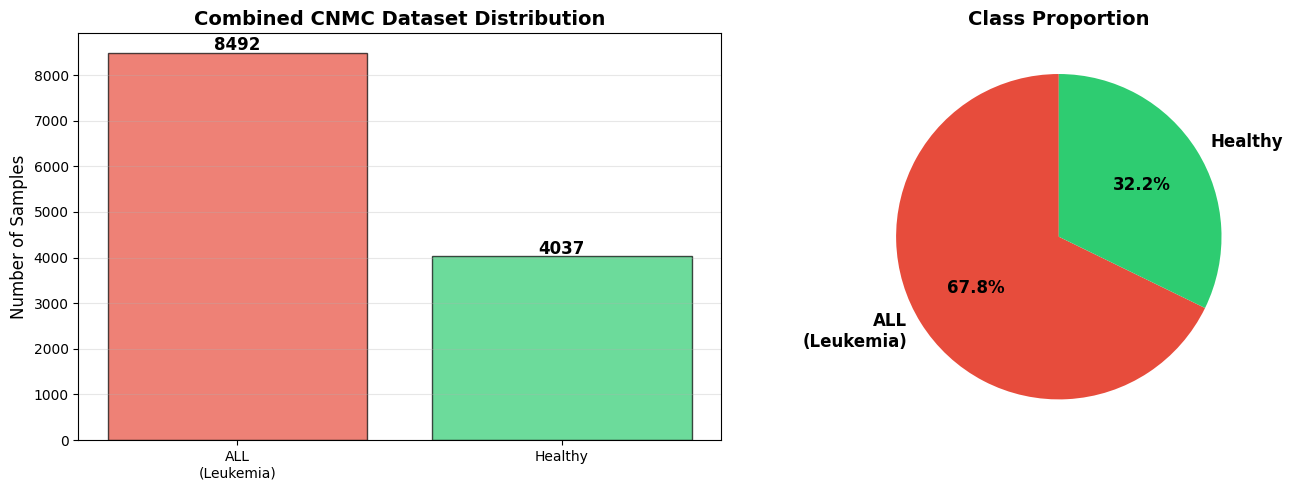


✓ Dataset is imbalanced


In [8]:
# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
class_names = ['ALL\n(Leukemia)', 'Healthy']
counts = [label_counts[0], label_counts[1]]
colors = ['#e74c3c', '#2ecc71']

axes[0].bar(class_names, counts, color=colors, alpha=0.7, edgecolor='black')
axes[0].set_ylabel('Number of Samples', fontsize=12)
axes[0].set_title('Combined CNMC Dataset Distribution', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

for i, (name, count) in enumerate(zip(class_names, counts)):
    axes[0].text(i, count + 50, str(count), ha='center', fontsize=12, fontweight='bold')

# Pie chart
axes[1].pie(counts, labels=class_names, autopct='%1.1f%%', colors=colors,
            startangle=90, textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title('Class Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n✓ Dataset is {'balanced' if abs(counts[0] - counts[1]) / max(counts) < 0.1 else 'imbalanced'}")

## Step 5: Create Stratified Splits

In [9]:
# ============================================================================
# MODIFIED: Create BALANCED Public Anchor and Public Test Sets
# ============================================================================
print("\nCreating balanced splits for Public Anchor and Public Test...")

# Separate indices by class
indices_all = np.where(labels == 0)[0]
indices_hem = np.where(labels == 1)[0]

# Shuffle indices (random_state=42 for reproducibility)
np.random.seed(42)
np.random.shuffle(indices_all)
np.random.shuffle(indices_hem)

# Calculate subset sizes based on defined ratios
total_samples = len(labels)
n_public_test_target = int(total_samples * PUBLIC_TEST_RATIO)
n_public_anchor_target = int(total_samples * PUBLIC_ANCHOR_RATIO)

# Ensure strictly balanced splits (50% ALL, 50% Healthy) for public sets
# We take N/2 from each class
n_test_per_class = n_public_test_target // 2
n_anchor_per_class = n_public_anchor_target // 2

print(f"Target Balanced Sizes:")
print(f"  Public Test: {n_test_per_class} ALL + {n_test_per_class} Healthy = {n_test_per_class*2} total")
print(f"  Public Anchor: {n_anchor_per_class} ALL + {n_anchor_per_class} Healthy = {n_anchor_per_class*2} total")

# Check if we have enough samples
min_required_all = n_test_per_class + n_anchor_per_class
min_required_hem = n_test_per_class + n_anchor_per_class

if len(indices_all) < min_required_all or len(indices_hem) < min_required_hem:
    print(f"⚠️ Warning: Not enough samples for balanced split!")
    print(f"  Required per class: {n_test_per_class + n_anchor_per_class}")
    print(f"  Available: ALL={len(indices_all)}, Healthy={len(indices_hem)}")

# Select indices for Public Test (balanced)
test_indices = np.concatenate([
    indices_all[:n_test_per_class],
    indices_hem[:n_test_per_class]
])

# Select indices for Public Anchor (balanced)
anchor_indices = np.concatenate([
    indices_all[n_test_per_class:n_test_per_class + n_anchor_per_class],
    indices_hem[n_test_per_class:n_test_per_class + n_anchor_per_class]
])

# Select remaining indices for Private Data (whatever is left)
private_indices = np.concatenate([
    indices_all[n_test_per_class + n_anchor_per_class:],
    indices_hem[n_test_per_class + n_anchor_per_class:]
])

# Create the splits
X_public_test = image_paths[test_indices]
y_public_test = labels[test_indices]

X_public_anchor = image_paths[anchor_indices]
y_public_anchor = labels[anchor_indices]

X_private = image_paths[private_indices]
y_private = labels[private_indices]

# Shuffle the splits internally
p_test = np.random.permutation(len(X_public_test))
X_public_test = X_public_test[p_test]
y_public_test = y_public_test[p_test]

p_anchor = np.random.permutation(len(X_public_anchor))
X_public_anchor = X_public_anchor[p_anchor]
y_public_anchor = y_public_anchor[p_anchor]

p_private = np.random.permutation(len(X_private))
X_private = X_private[p_private]
y_private = y_private[p_private]

print(f"\n{'='*60}")
print(f"Data Split Summary (BALANCED for Public Sets):")
print(f"{'='*60}")
print(f"Total samples: {len(labels)}")
print(f"\nPublic Anchor (for distillation):")
print(f"  Total: {len(X_public_anchor)} ({len(X_public_anchor)/len(labels)*100:.1f}%)")
print(f"  ALL: {sum(y_public_anchor == 0)}, Healthy: {sum(y_public_anchor == 1)}")
print(f"  Balance ratio: {min(sum(y_public_anchor == 0), sum(y_public_anchor == 1)) / max(sum(y_public_anchor == 0), sum(y_public_anchor == 1)):.2f}")

print(f"\nPublic Test (for evaluation):")
print(f"  Total: {len(X_public_test)} ({len(X_public_test)/len(labels)*100:.1f}%)")
print(f"  ALL: {sum(y_public_test == 0)}, Healthy: {sum(y_public_test == 1)}")
print(f"  Balance ratio: {min(sum(y_public_test == 0), sum(y_public_test == 1)) / max(sum(y_public_test == 0), sum(y_public_test == 1)):.2f}")

print(f"\nPrivate Data (for clients):")
print(f"  Total: {len(X_private)} ({len(X_private)/len(labels)*100:.1f}%)")
print(f"  ALL: {sum(y_private == 0)}, Healthy: {sum(y_private == 1)}")



Data Split Summary:
Total samples: 12529

Public Anchor (for distillation):
  Total: 1880 (15.0%)
  ALL: 1274, Healthy: 606

Public Test (for evaluation):
  Total: 1880 (15.0%)
  ALL: 1274, Healthy: 606

Private Data (for clients):
  Total: 8769 (70.0%)
  ALL: 5944, Healthy: 2825


## Step 6: Split Private Data Among Clients

In [10]:
def split_data_for_clients(X_private, y_private, num_clients, distribution='balanced', custom_ratios=None):
    """
    Split private data among multiple clients.

    Args:
        X_private: Array of image paths
        y_private: Array of labels
        num_clients: Number of clients to create
        distribution: 'balanced', 'imbalanced', or 'custom'
        custom_ratios: List of ratios for each client (for 'custom' mode)

    Returns:
        List of (X_client, y_client) tuples
    """
    client_data = []

    if distribution == 'balanced':
        # Equal split among clients
        indices = np.arange(len(X_private))
        np.random.shuffle(indices)

        client_size = len(X_private) // num_clients

        for i in range(num_clients):
            start_idx = i * client_size
            end_idx = start_idx + client_size if i < num_clients - 1 else len(X_private)

            client_indices = indices[start_idx:end_idx]
            client_data.append((X_private[client_indices], y_private[client_indices]))

    elif distribution == 'imbalanced':
        # Create power-law distribution (first client gets most data)
        # Ratios: [0.5, 0.3, 0.2] for 3 clients, adjusted for num_clients
        ratios = np.array([1.0 / (i + 1) for i in range(num_clients)])
        ratios = ratios / ratios.sum()  # Normalize

        indices = np.arange(len(X_private))
        np.random.shuffle(indices)

        current_idx = 0
        for ratio in ratios:
            client_size = int(len(X_private) * ratio)
            client_indices = indices[current_idx:current_idx + client_size]
            client_data.append((X_private[client_indices], y_private[client_indices]))
            current_idx += client_size

    elif distribution == 'custom':
        if custom_ratios is None or len(custom_ratios) != num_clients:
            raise ValueError(f"Custom ratios must be provided for {num_clients} clients")

        if not np.isclose(sum(custom_ratios), 1.0):
            raise ValueError(f"Custom ratios must sum to 1.0, got {sum(custom_ratios)}")

        indices = np.arange(len(X_private))
        np.random.shuffle(indices)

        current_idx = 0
        for ratio in custom_ratios:
            client_size = int(len(X_private) * ratio)
            client_indices = indices[current_idx:current_idx + client_size]
            client_data.append((X_private[client_indices], y_private[client_indices]))
            current_idx += client_size

    return client_data

# Split data among clients
client_datasets = split_data_for_clients(
    X_private, y_private,
    NUM_CLIENTS,
    CLIENT_DISTRIBUTION,
    CUSTOM_CLIENT_RATIOS
)

print(f"\n{'='*60}")
print(f"Client Data Distribution ({CLIENT_DISTRIBUTION}):")
print(f"{'='*60}")

for i, (X_client, y_client) in enumerate(client_datasets):
    print(f"\nClient {i}:")
    print(f"  Total samples: {len(X_client)}")
    print(f"  ALL: {sum(y_client == 0)}, Healthy: {sum(y_client == 1)}")
    print(f"  Balance ratio: {min(sum(y_client == 0), sum(y_client == 1)) / max(sum(y_client == 0), sum(y_client == 1)):.2f}")


Client Data Distribution (balanced):

Client 0:
  Total samples: 4384
  ALL: 2994, Healthy: 1390
  Balance ratio: 0.46

Client 1:
  Total samples: 4385
  ALL: 2950, Healthy: 1435
  Balance ratio: 0.49


## Step 7: Create Output Directory Structure

In [11]:
def create_dataset_structure(X, y, output_path, description):
    """
    Create ImageFolder structure: output_path/all and output_path/hem
    """
    print(f"\nCreating {description}...")

    # Create directories
    all_dir = os.path.join(output_path, 'all')  # ALL/Leukemia (label=0)
    hem_dir = os.path.join(output_path, 'hem')  # Healthy (label=1)

    os.makedirs(all_dir, exist_ok=True)
    os.makedirs(hem_dir, exist_ok=True)

    # Copy images to appropriate folders
    all_count = 0
    hem_count = 0

    for img_path, label in zip(X, y):
        # Determine destination folder
        if label == 0:  # ALL
            dest_dir = all_dir
            all_count += 1
        else:  # Healthy
            dest_dir = hem_dir
            hem_count += 1

        # Create unique filename
        img_filename = os.path.basename(img_path)
        dest_path = os.path.join(dest_dir, img_filename)

        # Handle duplicate filenames
        counter = 1
        while os.path.exists(dest_path):
            name, ext = os.path.splitext(img_filename)
            dest_path = os.path.join(dest_dir, f"{name}_{counter}{ext}")
            counter += 1

        # Copy image
        try:
            shutil.copy2(img_path, dest_path)
        except Exception as e:
            print(f"  ⚠️  Error copying {img_path}: {e}")

    print(f"  ✓ Created: {output_path}")
    print(f"    ALL: {all_count} images")
    print(f"    Healthy: {hem_count} images")

    return all_count, hem_count

# Clean output directory if it exists
if os.path.exists(OUTPUT_PATH):
    print(f"\n⚠️  Warning: Output directory exists: {OUTPUT_PATH}")
    print("Cleaning existing datasets...")
    shutil.rmtree(OUTPUT_PATH)

os.makedirs(OUTPUT_PATH, exist_ok=True)

print(f"\n{'='*60}")
print(f"Creating Output Datasets:")
print(f"{'='*60}")


Creating Output Datasets:


In [12]:
# Create public anchor dataset
anchor_all, anchor_hem = create_dataset_structure(
    X_public_anchor, y_public_anchor,
    PUBLIC_ANCHOR_PATH,
    "Public Anchor Dataset (for consensus distillation)"
)


Creating Public Anchor Dataset (for consensus distillation)...
  ✓ Created: /content/drive/MyDrive/College/FLEX-Med/cnmc_datasets/cnmc_public_anchor
    ALL: 1274 images
    Healthy: 606 images


In [13]:
# Create public test dataset
test_all, test_hem = create_dataset_structure(
    X_public_test, y_public_test,
    PUBLIC_TEST_PATH,
    "Public Test Dataset (for evaluation)"
)


Creating Public Test Dataset (for evaluation)...
  ✓ Created: /content/drive/MyDrive/College/FLEX-Med/cnmc_datasets/cnmc_public_test
    ALL: 1274 images
    Healthy: 606 images


In [14]:
# Create client datasets
client_stats = []

for i, (X_client, y_client) in enumerate(client_datasets):
    client_path = os.path.join(OUTPUT_PATH, f"cnmc_client_{i}")
    all_count, hem_count = create_dataset_structure(
        X_client, y_client,
        client_path,
        f"Client {i} Private Dataset"
    )
    client_stats.append({
        'client_id': i,
        'total': len(X_client),
        'all': all_count,
        'healthy': hem_count
    })


Creating Client 0 Private Dataset...
  ✓ Created: /content/drive/MyDrive/College/FLEX-Med/cnmc_datasets/cnmc_client_0
    ALL: 2994 images
    Healthy: 1390 images

Creating Client 1 Private Dataset...
  ✓ Created: /content/drive/MyDrive/College/FLEX-Med/cnmc_datasets/cnmc_client_1
    ALL: 2950 images
    Healthy: 1435 images


## Step 8: Create Summary Report

In [15]:
# Generate summary report
summary_report = {
    'total_samples': len(all_data),
    'public_anchor': {
        'total': len(X_public_anchor),
        'all': anchor_all,
        'healthy': anchor_hem,
        'percentage': len(X_public_anchor) / len(all_data) * 100
    },
    'public_test': {
        'total': len(X_public_test),
        'all': test_all,
        'healthy': test_hem,
        'percentage': len(X_public_test) / len(all_data) * 100
    },
    'clients': client_stats
}

# Save summary as JSON
import json
summary_path = os.path.join(OUTPUT_PATH, 'dataset_summary.json')
with open(summary_path, 'w') as f:
    json.dump(summary_report, f, indent=2)

print(f"\n{'='*60}")
print(f"Final Summary:")
print(f"{'='*60}")
print(json.dumps(summary_report, indent=2))
print(f"\n✓ Summary saved to: {summary_path}")


Final Summary:
{
  "total_samples": 12529,
  "public_anchor": {
    "total": 1880,
    "all": 1274,
    "healthy": 606,
    "percentage": 15.005187963923698
  },
  "public_test": {
    "total": 1880,
    "all": 1274,
    "healthy": 606,
    "percentage": 15.005187963923698
  },
  "clients": [
    {
      "client_id": 0,
      "total": 4384,
      "all": 2994,
      "healthy": 1390
    },
    {
      "client_id": 1,
      "total": 4385,
      "all": 2950,
      "healthy": 1435
    }
  ]
}

✓ Summary saved to: /content/drive/MyDrive/College/FLEX-Med/cnmc_datasets/dataset_summary.json


## Step 9: Visualize Final Distribution

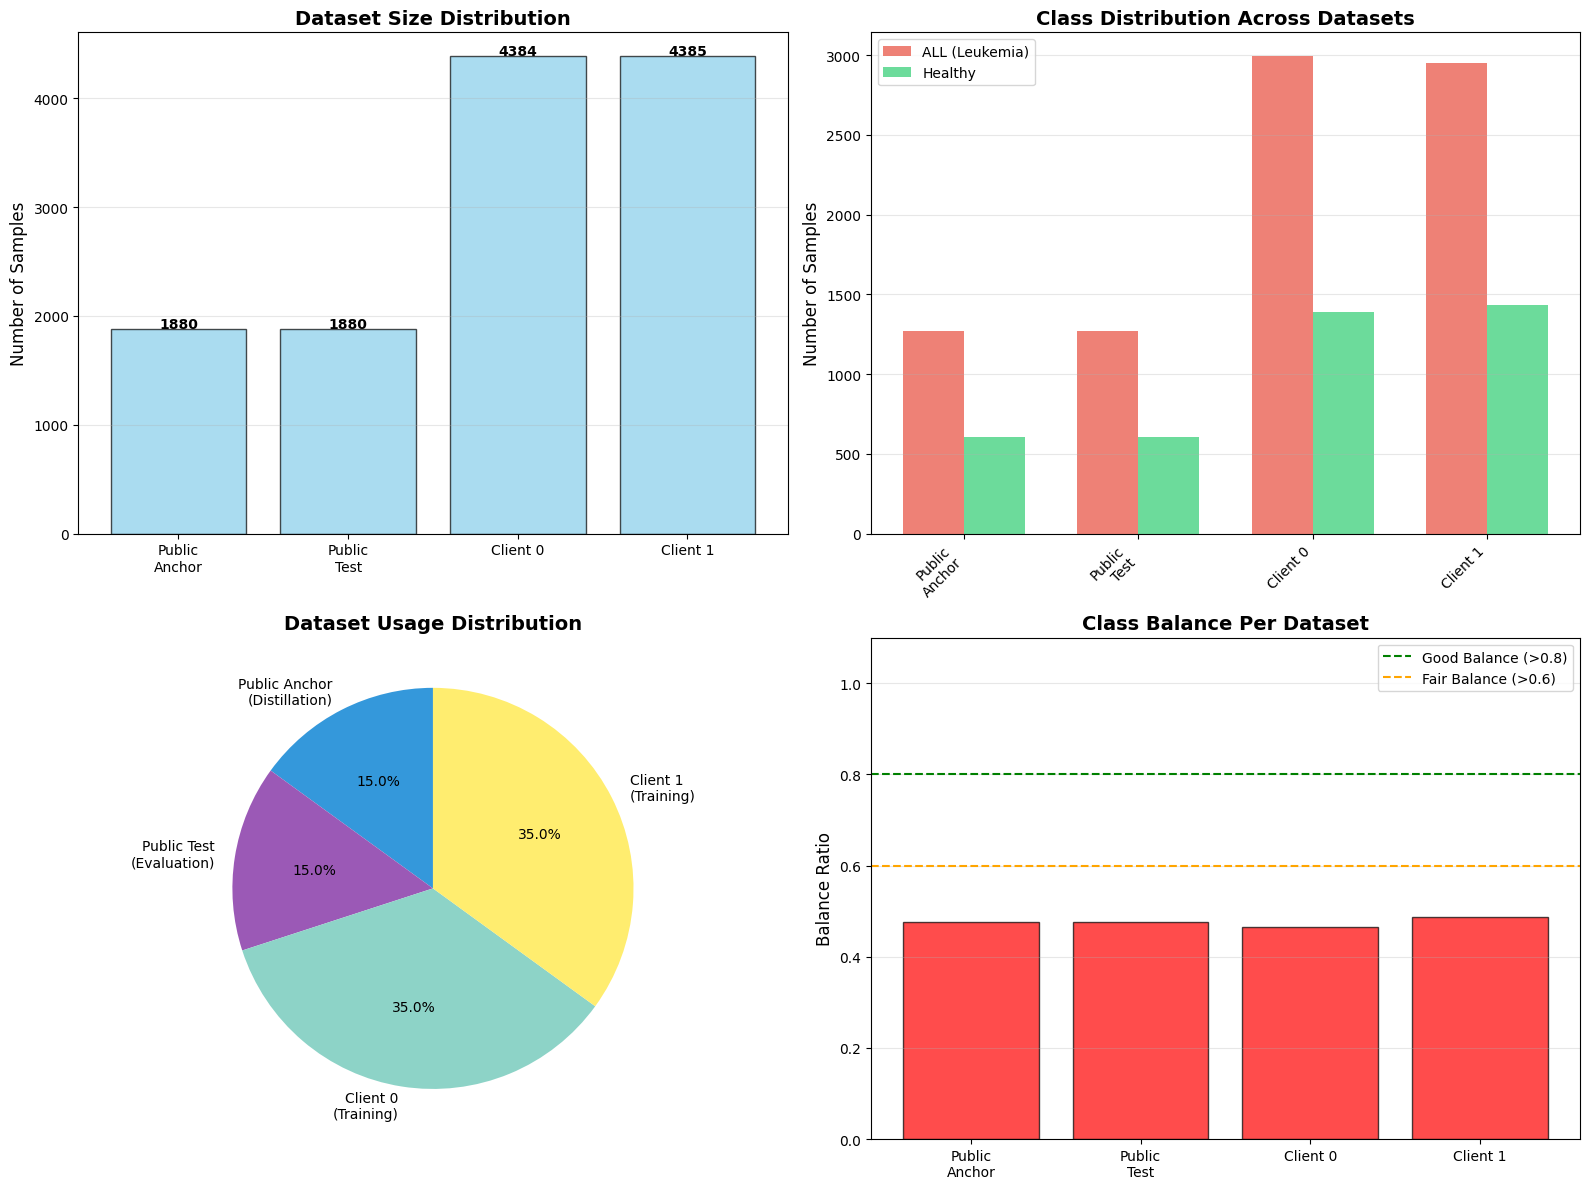


✓ Visualization saved to: /content/drive/MyDrive/College/FLEX-Med/cnmc_datasets/dataset_distribution.png


In [16]:
# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Overall distribution
datasets = ['Public\nAnchor', 'Public\nTest'] + [f'Client {i}' for i in range(NUM_CLIENTS)]
totals = [len(X_public_anchor), len(X_public_test)] + [stats['total'] for stats in client_stats]

axes[0, 0].bar(datasets, totals, color='skyblue', alpha=0.7, edgecolor='black')
axes[0, 0].set_ylabel('Number of Samples', fontsize=12)
axes[0, 0].set_title('Dataset Size Distribution', fontsize=14, fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)
for i, (ds, total) in enumerate(zip(datasets, totals)):
    axes[0, 0].text(i, total + 10, str(total), ha='center', fontsize=10, fontweight='bold')

# Plot 2: Class distribution across datasets
x = np.arange(len(datasets))
width = 0.35

all_counts = [anchor_all, test_all] + [stats['all'] for stats in client_stats]
hem_counts = [anchor_hem, test_hem] + [stats['healthy'] for stats in client_stats]

axes[0, 1].bar(x - width/2, all_counts, width, label='ALL (Leukemia)', color='#e74c3c', alpha=0.7)
axes[0, 1].bar(x + width/2, hem_counts, width, label='Healthy', color='#2ecc71', alpha=0.7)
axes[0, 1].set_ylabel('Number of Samples', fontsize=12)
axes[0, 1].set_title('Class Distribution Across Datasets', fontsize=14, fontweight='bold')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(datasets, rotation=45, ha='right')
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

# Plot 3: Percentage distribution pie chart
sizes = [len(X_public_anchor), len(X_public_test)] + [stats['total'] for stats in client_stats]
labels_pie = ['Public Anchor\n(Distillation)', 'Public Test\n(Evaluation)'] + [f'Client {i}\n(Training)' for i in range(NUM_CLIENTS)]
colors_pie = ['#3498db', '#9b59b6'] + plt.cm.Set3(np.linspace(0, 1, NUM_CLIENTS)).tolist()

axes[1, 0].pie(sizes, labels=labels_pie, autopct='%1.1f%%', colors=colors_pie,
               startangle=90, textprops={'fontsize': 10})
axes[1, 0].set_title('Dataset Usage Distribution', fontsize=14, fontweight='bold')

# Plot 4: Balance ratio per dataset
balance_ratios = []
for all_c, hem_c in zip(all_counts, hem_counts):
    ratio = min(all_c, hem_c) / max(all_c, hem_c) if max(all_c, hem_c) > 0 else 0
    balance_ratios.append(ratio)

colors_bar = ['green' if r > 0.8 else 'orange' if r > 0.6 else 'red' for r in balance_ratios]
axes[1, 1].bar(datasets, balance_ratios, color=colors_bar, alpha=0.7, edgecolor='black')
axes[1, 1].axhline(y=0.8, color='green', linestyle='--', label='Good Balance (>0.8)')
axes[1, 1].axhline(y=0.6, color='orange', linestyle='--', label='Fair Balance (>0.6)')
axes[1, 1].set_ylabel('Balance Ratio', fontsize=12)
axes[1, 1].set_title('Class Balance Per Dataset', fontsize=14, fontweight='bold')
axes[1, 1].set_ylim(0, 1.1)
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'dataset_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Visualization saved to: {os.path.join(OUTPUT_PATH, 'dataset_distribution.png')}")

## Step 10: Completion Summary

In [17]:
print(f"\n{'='*70}")
print(f"✓ CNMC Dataset Preparation Complete!")
print(f"{'='*70}")
print(f"\nOutput directory: {OUTPUT_PATH}")
print(f"  (Separate from existing /FLEX-Med/datasets/)")
print(f"\nCreated datasets:")
print(f"  1. cnmc_public_anchor/    - {len(X_public_anchor)} samples (distillation)")
print(f"  2. cnmc_public_test/      - {len(X_public_test)} samples (evaluation)")
for i in range(NUM_CLIENTS):
    print(f"  {i+3}. cnmc_client_{i}/        - {client_stats[i]['total']} samples (training)")

print(f"\n{'='*70}")
print(f"Next Steps to Use CNMC Datasets in FL:")
print(f"{'='*70}")

print(f"\n1. Update task.py paths (ONLY FOR CNMC RUNS):")
print(f"   PUBLIC_ANCHOR_DATASET_PATH = '{PUBLIC_ANCHOR_PATH}'")
print(f"   PUBLIC_TEST_DATASET_PATH = '{PUBLIC_TEST_PATH}'")

print(f"\n2. Create NEW data.json for CNMC (e.g., cnmc_data.json):")
print(f"   [")
for i in range(NUM_CLIENTS):
    client_path = os.path.join(OUTPUT_PATH, f"cnmc_client_{i}")
    model_path = os.path.join(BASE_PATH, f"FLEX-Med/models/cnmc_client_{i}_model.pt")
    print(f"     {{")
    print(f"       \"id\": {i},")
    print(f"       \"client_name\": \"CNMC-Client-{i}\",")
    print(f"       \"model_type\": \"resnet18\",  # or mobilenet_v2")
    print(f"       \"has_local_data\": true,")
    print(f"       \"dataset_path\": \"{client_path}\",")
    print(f"       \"model_path\": \"{model_path}\",")
    print(f"       \"metrics\": \"{{}}\"")
    print(f"     }}{'' if i == NUM_CLIENTS - 1 else ','}")
print(f"   ]")

print(f"\n3. Run FL with CNMC config:")
print(f"   export FLEX_MED_CONFIG_FILE=/path/to/cnmc_data.json")
print(f"   cd federated_learning")
print(f"   flwr run .")

print(f"\n4. Verify Focal Loss handles class imbalance:")
print(f"   Watch for: 'Leukemia: X%, Healthy: Y%, Gap: Z%'")
print(f"   Target: Both >75%, Gap <20%")

print(f"\n{'='*70}")
print(f"Dataset Summary:")
print(f"{'='*70}")
print(f"Total CNMC samples used: {len(all_data)}")
print(f"  Class distribution: ~2.1:1 (Leukemia:Healthy)")
print(f"  Handled by: Focal Loss (alpha=0.25, gamma=2.0)")
print(f"\nPublic Anchor: {len(X_public_anchor)} ({PUBLIC_ANCHOR_RATIO*100:.0f}%)")
print(f"Public Test: {len(X_public_test)} ({PUBLIC_TEST_RATIO*100:.0f}%)")
print(f"Client Training: {len(X_private)} ({PRIVATE_DATA_RATIO*100:.0f}%)")
print(f"  Per client (balanced): ~{len(X_private)//NUM_CLIENTS} samples")
print(f"\n⚠️  This setup is ISOLATED - existing datasets/ directory untouched")
print(f"{'='*70}")


✓ CNMC Dataset Preparation Complete!

Output directory: /content/drive/MyDrive/College/FLEX-Med/cnmc_datasets
  (Separate from existing /FLEX-Med/datasets/)

Created datasets:
  1. cnmc_public_anchor/    - 1880 samples (distillation)
  2. cnmc_public_test/      - 1880 samples (evaluation)
  3. cnmc_client_0/        - 4384 samples (training)
  4. cnmc_client_1/        - 4385 samples (training)

Next Steps to Use CNMC Datasets in FL:

1. Update task.py paths (ONLY FOR CNMC RUNS):
   PUBLIC_ANCHOR_DATASET_PATH = '/content/drive/MyDrive/College/FLEX-Med/cnmc_datasets/cnmc_public_anchor'
   PUBLIC_TEST_DATASET_PATH = '/content/drive/MyDrive/College/FLEX-Med/cnmc_datasets/cnmc_public_test'

2. Create NEW data.json for CNMC (e.g., cnmc_data.json):
   [
     {
       "id": 0,
       "client_name": "CNMC-Client-0",
       "model_type": "resnet18",  # or mobilenet_v2
       "has_local_data": true,
       "dataset_path": "/content/drive/MyDrive/College/FLEX-Med/cnmc_datasets/cnmc_client_0",
    